In [1]:
import sys

sys.path.append('../')
from const import *
from train import *

In [29]:
with open('../models/2025-03-31_11-55-24/forecasts_49.pkl', 'rb') as f:
    forecasts = pickle.load(f)

forecasts = np.vstack(forecasts)
print(forecasts.shape)

(51963, 100, 12)


In [30]:
forecasts_percentile = np.median(forecasts, 1)
forecasts_percentile[forecasts_percentile<0] = 0.0
forecasts_percentile = np.expm1(forecasts_percentile)

In [20]:
for index in range(10):
    forecasts_percentile = [
        data[np.delete(np.arange(100), np.unique(np.where((data<np.percentile(data, 10-index, axis=0)) | (data>np.percentile(data, 90+index, axis=0)))[0])),:]
        for data in forecasts
    ]
    len_list = [len(data)for data in forecasts_percentile]
    if min(len_list)>10:
        print('Percentile = [%d, %d]'%(10-index, 90+index))
        break
forecasts_percentile = np.array([np.expm1(np.median(data, axis=0)) for data in forecasts])

Percentile = [5, 95]


In [31]:
config = get_config()
train_dataset, val_dataset, predict_dataset = load_dataset(DATASET_WEEK_PATH)
train_dataloader, val_dataloader, predict_dataloader = get_dataloader(
    train_dataset, val_dataset, predict_dataset, config
)

In [32]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

def plot(ts_index):
    fig, ax = plt.subplots()

    index = pd.period_range(
        start=predict_dataset[ts_index][FieldName.START],
        periods=len(predict_dataset[ts_index][FieldName.TARGET]),
        freq=FREQ,
    ).to_timestamp()

    # Major ticks every half year, minor ticks every month,
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7)))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())

    ax.plot(
        #index[-2*PREDICTION_LENGTH:], 
        index[-65:], 
        #np.array(predict_dataset[ts_index]["target"][-65:]),
        np.expm1(predict_dataset[ts_index]["target"][-65:]),
        label="actual",
    )

    plt.plot(
        index[-PREDICTION_LENGTH:], 
        #np.array(np.median(forecasts[ts_index], axis=0)),
        forecasts_percentile[ts_index],
        label="median",
    )
    plt.legend()
    plt.show()

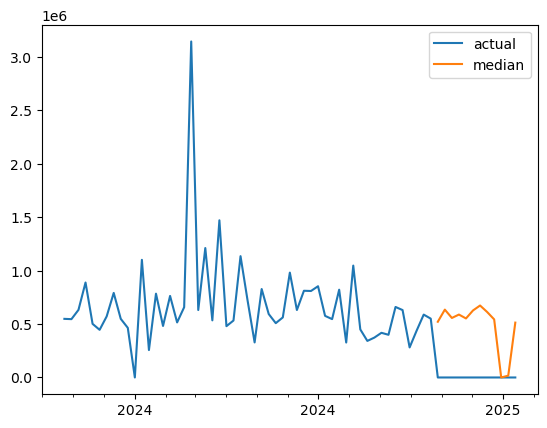

In [34]:
plot(321)

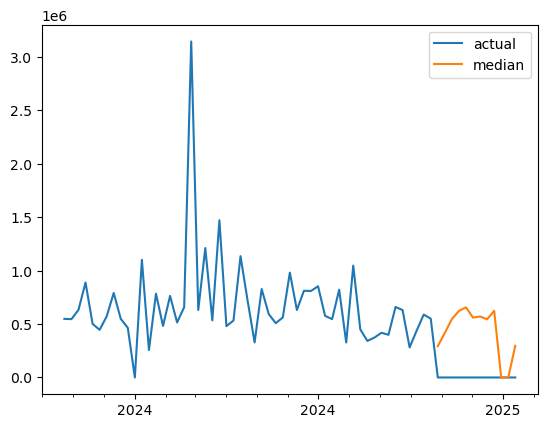

In [28]:
plot(321)

In [3]:
config = get_config()
train_dataset, val_dataset, predict_dataset = load_dataset(DATASET_WEEK_PATH)
train_dataloader, val_dataloader, predict_dataloader = get_dataloader(
    train_dataset, val_dataset, predict_dataset, config
)
model_path = MODELS_PATH / '2025-03-06_22-45-11/checkpoint-epoch=26-train_loss=0.7764-sMAPE_vall=0.1453'
inference(model_path, train_dataloader, val_dataloader, config)

2025-03-07,15:23:42 Loading states from /mnt/data/ods/example/../models/2025-03-06_22-45-11/checkpoint-epoch=26-train_loss=0.7764-sMAPE_vall=0.1453
2025-03-07,15:23:42 All model weights loaded successfully
2025-03-07,15:23:42 All optimizer states loaded successfully
2025-03-07,15:23:42 All scheduler states loaded successfully
2025-03-07,15:23:42 All dataloader sampler states loaded successfully
2025-03-07,15:23:42 All random states loaded successfully
2025-03-07,15:23:42 Loading in 0 custom states
51it [02:39,  3.13s/it]
2025-03-07,15:26:22 Forecasts path: /mnt/data/ods/example/../models/2025-03-06_22-45-11/forecasts_26.pkl


In [2]:
config = get_config()
train_dataset, val_dataset, predict_dataset = load_dataset(DATASET_WEEK_PATH, add_val=True)
train_dataloader, val_dataloader, predict_dataloader = get_dataloader(
    train_dataset, val_dataset, predict_dataset, config
)

with open('../models/2025-03-21_00-35-37/forecasts_75.pkl', 'rb') as f:
    forecasts = pickle.load(f)

forecasts = np.vstack(forecasts)
print(forecasts.shape)

(51963, 100, 12)


In [3]:
forecast_median = np.median(forecasts, 1)
forecast_median = np.expm1(forecast_median)
forecast_median.mean()

2156287.8

In [4]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

def plot(ts_index):
    fig, ax = plt.subplots()

    index = pd.period_range(
        start=val_dataset[ts_index][FieldName.START],
        periods=len(val_dataset[ts_index][FieldName.TARGET]),
        freq=FREQ,
    ).to_timestamp()

    # Major ticks every half year, minor ticks every month,
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7)))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())

    ax.plot(
        index[-PREDICTION_LENGTH-53:], 
        np.expm1(np.array(val_dataset[ts_index]["target"][-PREDICTION_LENGTH-53:])),
        label="actual",
    )

    plt.plot(
        index[-PREDICTION_LENGTH:], 
        np.expm1(np.median(forecasts[ts_index], axis=0)),
        #np.expm1(forecasts_percentile[ts_index]),
        #np.expm1(forecasts_percentile[ts_index][0]),
        #np.expm1(forecasts[ts_index][7]),
        label="median",
    )
    
    plt.fill_between(
        index[-PREDICTION_LENGTH:],
        np.expm1(forecasts[ts_index].mean(0)) - np.expm1(forecasts[ts_index].std(axis=0)), 
        np.expm1(forecasts[ts_index].mean(0)) + np.expm1(forecasts[ts_index].std(axis=0)), 
        alpha=0.3, 
        interpolate=True,
        label="+/- 1-std",
    )
    plt.legend()
    plt.show()

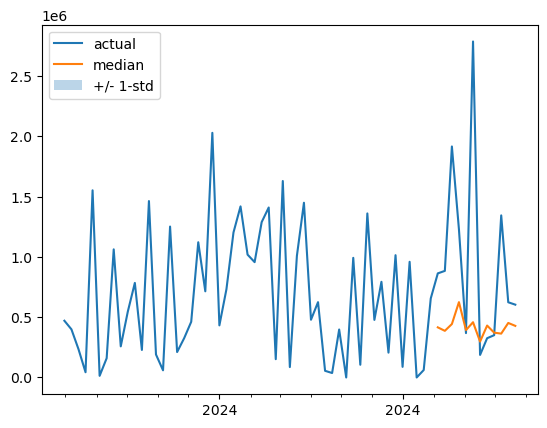

In [21]:
plot(2134)